# Dzień 4 - Analiza statystyczna: percentyle, momentum, test hipotezy

**Cel:** Odpowiedzieć na pytania:
1. Gdzie jesteśmy dziś vs historia 1990-2026? (percentyle wskaźników)
2. Jak zmienia się dynamika M2? (momentum)
3. Jak realna stopa Fed wyglądała per dekada?
4. Czy ujemna realna stopa Fed → ponadprzeciętne zwroty S&P500? (test hipotezy)

**Dane:** `data/fed_cycles.db` → widok `v_master` (436 miesięcy, 1990-2026)

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Połączenie z bazą
conn = sqlite3.connect('../data/fed_cycles.db')
df = pd.read_sql('SELECT * FROM v_master', conn)
conn.close()

df['ym'] = pd.to_datetime(df['ym'])
df = df.set_index('ym').sort_index()

print(f'Zakres dat: {df.index.min().strftime("%Y-%m")} → {df.index.max().strftime("%Y-%m")}')
print(f'Liczba wierszy: {len(df)}')
df.tail(3)

Zakres dat: 1990-01 → 2026-09
Liczba wierszy: 441


,fedfunds,m2sl,sp500,t10y2y,usrec,unrate,gdpc1,cpiaucsl,icsa,payems,indpro,rsxfs,permit,hy_spread,credit_cond,lei,vix
ym,,,,,,,,,,,,,,,,,
2026-07-01,3.63,23218.0,7481.339089,0.376818,0.0,4.1,NaN,332.813,203250.0,158913.0,102.9939,660047.0,1433.0,2.743478,0.0,NaN,17.149091
2026-08-01,3.63,NaN,7711.323335,0.468095,0.0,4.1,NaN,334.131,206000.0,159075.0,NaN,NaN,NaN,2.701429,NaN,NaN,15.229524
2026-09-01,NaN,NaN,7643.747709,0.396250,NaN,NaN,NaN,NaN,206000.0,NaN,NaN,NaN,NaN,2.675000,NaN,NaN,15.986429


## 1. Percentyle historyczne - gdzie jesteśmy dziś?

Dla każdego wskaźnika obliczamy percentyl aktualnej wartości na tle całej historii 1990-2026.
Percentyl 90+ = wysoko historycznie, percentyl 10- = nisko historycznie.

In [2]:
# Wskaźniki do analizy percentylowej
indicators = {
    'fedfunds':    'Stopa Fed (%)',
    't10y2y':      'Yield Curve 10Y-2Y (pp)',
    'm2sl':        'M2 (mld USD)',
    'unrate':      'Bezrobocie (%)',
    'cpiaucsl':    'CPI (indeks)',
    'hy_spread':   'HY Spread (pp)',
    'credit_cond': 'Warunki kredytowe',
    'lei':         'LEI (wiodący)',
}

# Ostatni dostępny miesiąc
last_date = df.index.max()
last_row = df.loc[last_date]

results = []
for col, label in indicators.items():
    series = df[col].dropna()
    current = last_row[col]
    if pd.isna(current) or len(series) < 10:
        continue
    pct = stats.percentileofscore(series, current, kind='rank')
    results.append({
        'Wskaźnik': label,
        'Aktualna wartość': round(current, 2),
        'Min (1990-)': round(series.min(), 2),
        'Mediana': round(series.median(), 2),
        'Max': round(series.max(), 2),
        'Percentyl': round(pct, 1),
        'Ocena': '🔴 Wysoko' if pct >= 80 else ('🟡 Umiark.' if pct >= 40 else '🟢 Nisko'),
    })

pct_df = pd.DataFrame(results).set_index('Wskaźnik')
print(f'Data ostatniego pomiaru: {last_date.strftime("%Y-%m")}\n')
pct_df

Data ostatniego pomiaru: 2026-09



,Aktualna wartość,Min (1990-),Mediana,Max,Percentyl,Ocena
Wskaźnik,,,,,,
Yield Curve 10Y-2Y (pp),0.40,-0.93,0.82,2.83,32.2,🟢 Nisko
HY Spread (pp),2.68,2.54,4.51,20.31,2.2,🟢 Nisko


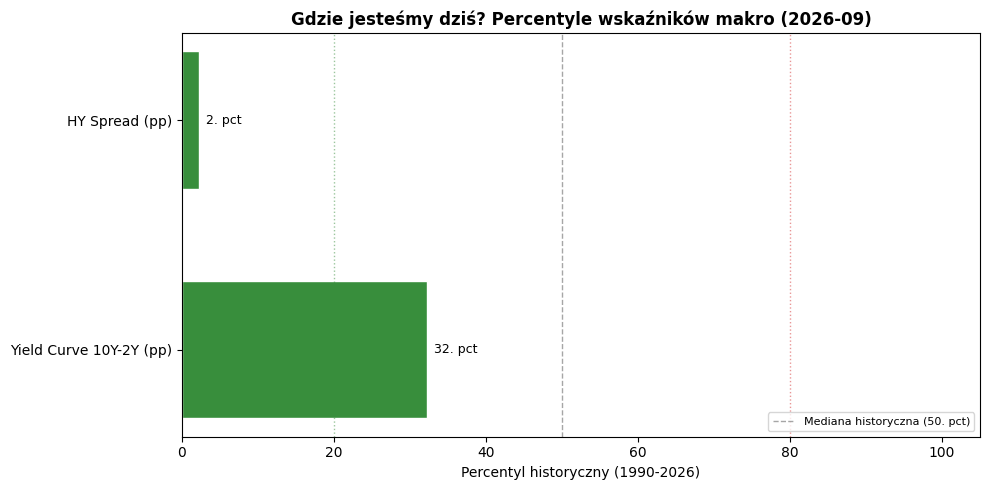

Zapisano: reports/01_percentyle_historyczne.png


In [3]:
# Wizualizacja percentyli - poziomy bar chart
fig, ax = plt.subplots(figsize=(10, 5))

labels = pct_df.index.tolist()
pcts   = pct_df['Percentyl'].values
colors = ['#d32f2f' if p >= 80 else ('#f9a825' if p >= 40 else '#388e3c') for p in pcts]

bars = ax.barh(labels, pcts, color=colors, edgecolor='white', height=0.6)
ax.axvline(50, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Mediana historyczna (50. pct)')
ax.axvline(80, color='#d32f2f', linestyle=':', linewidth=1, alpha=0.5)
ax.axvline(20, color='#388e3c', linestyle=':', linewidth=1, alpha=0.5)

for bar, val in zip(bars, pcts):
    ax.text(min(val + 1, 95), bar.get_y() + bar.get_height()/2,
            f'{val:.0f}. pct', va='center', fontsize=9)

ax.set_xlim(0, 105)
ax.set_xlabel('Percentyl historyczny (1990-2026)')
ax.set_title(f'Gdzie jesteśmy dziś? Percentyle wskaźników makro ({last_date.strftime("%Y-%m")})',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('../reports/01_percentyle_historyczne.png', dpi=150, bbox_inches='tight')
plt.show()
print('Zapisano: reports/01_percentyle_historyczne.png')

## 2. Momentum M2 - przyspieszenie i hamowanie podaży pieniądza

**M2 YoY** = zmiana roczna M2 (%)  
**M2 Momentum** = zmiana M2 YoY w ciągu ostatnich 6 miesięcy - pozytywny → podaż pieniądza przyspiesza

In [4]:
# Obliczenia
m2 = df['m2sl'].dropna()
m2_yoy   = m2.pct_change(12) * 100          # zmiana roczna %
m2_mom   = m2_yoy.diff(6)                   # momentum: zmiana YoY przez 6 mies.
m2_accel = m2_yoy.diff(1)                   # przyspieszenie: zmiana miesiąc do miesiąca

# Ostatnie wartości
print('=== Aktualny stan M2 ===')
print(f'M2 YoY (ostatni):       {m2_yoy.iloc[-1]:.2f}%')
print(f'M2 Momentum 6M:         {m2_mom.iloc[-1]:+.2f} pp')
print(f'M2 Przyspieszenie (MoM):{m2_accel.iloc[-1]:+.2f} pp')
print(f'Percentyl M2 YoY:       {stats.percentileofscore(m2_yoy.dropna(), m2_yoy.iloc[-1], kind="rank"):.0f}.')
print()
print('=== Historyczne ekstrema M2 YoY ===')
print(f'Min: {m2_yoy.min():.1f}% ({m2_yoy.idxmin().strftime("%Y-%m")})')
print(f'Max: {m2_yoy.max():.1f}% ({m2_yoy.idxmax().strftime("%Y-%m")})')

=== Aktualny stan M2 ===
M2 YoY (ostatni):       5.41%
M2 Momentum 6M:         +1.36 pp
M2 Przyspieszenie (MoM):+0.07 pp
Percentyl M2 YoY:       47.

=== Historyczne ekstrema M2 YoY ===
Min: -4.6% (2023-04)
Max: 26.8% (2021-02)


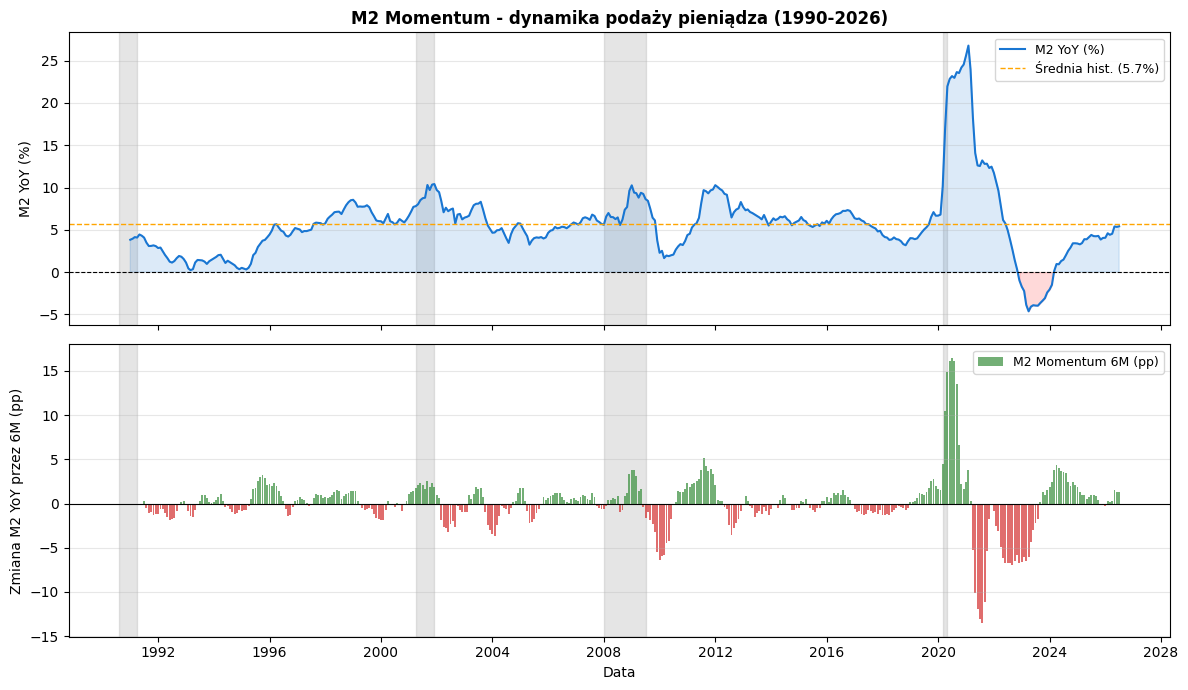

Zapisano: reports/02_m2_momentum.png


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Szare pasy recesji
rec = df['usrec'].reindex(m2_yoy.index).fillna(0)
rec_starts = rec[(rec == 1) & (rec.shift(1) == 0)].index
rec_ends   = rec[(rec == 0) & (rec.shift(1) == 1)].index

def add_recessions(ax):
    for s in rec_starts:
        e = rec_ends[rec_ends > s]
        end = e[0] if len(e) else m2_yoy.index[-1]
        ax.axvspan(s, end, color='gray', alpha=0.2)

# Panel 1: M2 YoY
ax = axes[0]
add_recessions(ax)
ax.plot(m2_yoy.index, m2_yoy, color='#1976d2', linewidth=1.5, label='M2 YoY (%)')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axhline(m2_yoy.mean(), color='orange', linewidth=1, linestyle='--',
           label=f'Średnia hist. ({m2_yoy.mean():.1f}%)')
ax.fill_between(m2_yoy.index, 0, m2_yoy, where=(m2_yoy > 0), alpha=0.15, color='#1976d2')
ax.fill_between(m2_yoy.index, 0, m2_yoy, where=(m2_yoy < 0), alpha=0.15, color='red')
ax.set_ylabel('M2 YoY (%)')
ax.set_title('M2 Momentum - dynamika podaży pieniądza (1990-2026)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Panel 2: M2 Momentum 6M
ax = axes[1]
add_recessions(ax)
colors_mom = ['#388e3c' if v >= 0 else '#d32f2f' for v in m2_mom.fillna(0)]
ax.bar(m2_mom.index, m2_mom, color=colors_mom, width=25, alpha=0.7, label='M2 Momentum 6M (pp)')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Zmiana M2 YoY przez 6M (pp)')
ax.set_xlabel('Data')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/02_m2_momentum.png', dpi=150, bbox_inches='tight')
plt.show()
print('Zapisano: reports/02_m2_momentum.png')

## 3. Realna stopa Fed per dekada

**Realna stopa Fed** = FEDFUNDS − CPI YoY  
Ujemna realna stopa = polityka akomodacyjna (pieniądz tani w ujęciu realnym)  
Dodatnia realna stopa = polityka restrykcyjna

In [6]:
# Obliczenie realnej stopy Fed
cpi_yoy = df['cpiaucsl'].pct_change(12) * 100
real_rate = df['fedfunds'] - cpi_yoy
real_rate.name = 'real_rate'

# Dekady
decade_labels = {
    '1990s': ('1990-01', '1999-12'),
    '2000s': ('2000-01', '2009-12'),
    '2010s': ('2010-01', '2019-12'),
    '2020s': ('2020-01', '2029-12'),
}

print('=== Realna stopa Fed per dekada ===')
decade_stats = []
for label, (start, end) in decade_labels.items():
    mask = (real_rate.index >= start) & (real_rate.index <= end)
    s = real_rate[mask].dropna()
    if len(s) == 0:
        continue
    row = {
        'Dekada': label,
        'Średnia (pp)': round(s.mean(), 2),
        'Mediana (pp)': round(s.median(), 2),
        'Min (pp)': round(s.min(), 2),
        'Max (pp)': round(s.max(), 2),
        'Mies. ujemnych (%)': round((s < 0).sum() / len(s) * 100, 1),
    }
    decade_stats.append(row)
    print(f'{label}: śr={row["Średnia (pp)"]:+.2f}pp | ujemnych: {row["Mies. ujemnych (%)"]:.0f}%')

print(f'\nAktualnie ({real_rate.dropna().index[-1].strftime("%Y-%m")}): {real_rate.dropna().iloc[-1]:+.2f} pp')
pd.DataFrame(decade_stats).set_index('Dekada')

=== Realna stopa Fed per dekada ===
1990s: śr=+2.08pp | ujemnych: 6%
2000s: śr=+0.38pp | ujemnych: 40%
2010s: śr=-1.16pp | ujemnych: 85%
2020s: śr=-1.08pp | ujemnych: 53%

Aktualnie (2026-08): +0.28 pp


,Średnia (pp),Mediana (pp),Min (pp),Max (pp),Mies. ujemnych (%)
Dekada,,,,,
1990s,2.08,2.41,-0.23,4.11,6.5
2000s,0.38,0.27,-3.49,3.84,40.0
2010s,-1.16,-1.04,-3.73,0.91,85.0
2020s,-1.08,-0.15,-8.37,2.72,53.2


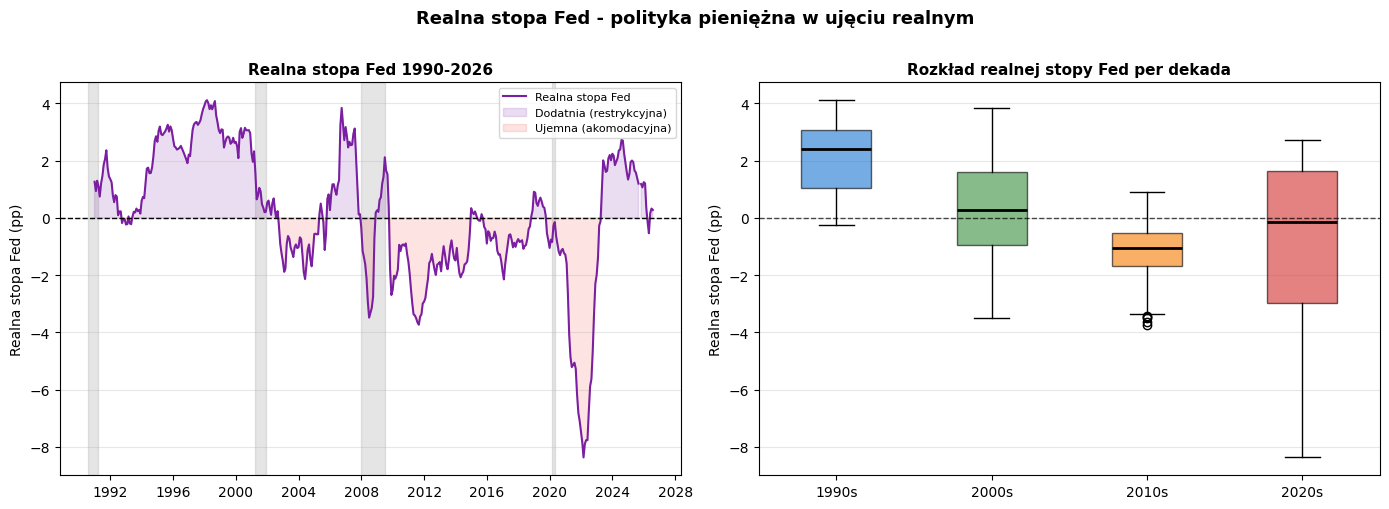

Zapisano: reports/03_realna_stopa_fed.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel lewy: szereg czasowy realnej stopy Fed
ax = axes[0]
add_recessions(ax)
ax.plot(real_rate.index, real_rate, color='#7b1fa2', linewidth=1.5, label='Realna stopa Fed')
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.fill_between(real_rate.index, 0, real_rate,
                where=(real_rate > 0), color='#7b1fa2', alpha=0.15, label='Dodatnia (restrykcyjna)')
ax.fill_between(real_rate.index, 0, real_rate,
                where=(real_rate < 0), color='#f44336', alpha=0.15, label='Ujemna (akomodacyjna)')
ax.set_ylabel('Realna stopa Fed (pp)')
ax.set_title('Realna stopa Fed 1990-2026', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Panel prawy: boxplot per dekada
ax = axes[1]
decade_data = []
decade_names = []
colors_box = ['#1976d2', '#388e3c', '#f57c00', '#d32f2f']

for label, (start, end) in decade_labels.items():
    mask = (real_rate.index >= start) & (real_rate.index <= end)
    s = real_rate[mask].dropna()
    if len(s) > 0:
        decade_data.append(s.values)
        decade_names.append(label)

bp = ax.boxplot(decade_data, labels=decade_names, patch_artist=True, notch=False,
                medianprops={'color': 'black', 'linewidth': 2})
for patch, color in zip(bp['boxes'], colors_box[:len(decade_data)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
ax.set_ylabel('Realna stopa Fed (pp)')
ax.set_title('Rozkład realnej stopy Fed per dekada', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Realna stopa Fed - polityka pieniężna w ujęciu realnym', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/03_realna_stopa_fed.png', dpi=150, bbox_inches='tight')
plt.show()
print('Zapisano: reports/03_realna_stopa_fed.png')

## 4. Test hipotezy: ujemna realna stopa Fed → ponadprzeciętne zwroty S&P500?

**Hipoteza (H₁):** W miesiącach z ujemną realną stopą Fed średni 12-miesięczny zwrot S&P500 jest wyższy niż w miesiącach z dodatnią realną stopą.

**Test:** t-test Welcha (nierówne wariancje) - poziom istotności α = 0.05

In [8]:
# Przygotowanie danych
sp500 = df['sp500'].dropna()
sp500_fwd12 = sp500.pct_change(12).shift(-12) * 100  # zwrot forward 12M

analysis = pd.DataFrame({
    'real_rate': real_rate,
    'sp500_fwd12': sp500_fwd12,
}).dropna()

neg_rate = analysis[analysis['real_rate'] < 0]['sp500_fwd12']
pos_rate = analysis[analysis['real_rate'] >= 0]['sp500_fwd12']

print('=== Statystyki opisowe ===')
print(f'Ujemna realna stopa (n={len(neg_rate)}):')
print(f'  Średni zwrot 12M: {neg_rate.mean():.1f}%  |  Mediana: {neg_rate.median():.1f}%  |  Std: {neg_rate.std():.1f}%')
print(f'Dodatnia realna stopa (n={len(pos_rate)}):')
print(f'  Średni zwrot 12M: {pos_rate.mean():.1f}%  |  Mediana: {pos_rate.median():.1f}%  |  Std: {pos_rate.std():.1f}%')

# T-test Welcha
t_stat, p_val = stats.ttest_ind(neg_rate, pos_rate, equal_var=False)
print(f'\n=== T-test Welcha ===')
print(f't-statystyka: {t_stat:.3f}')
print(f'p-wartość:    {p_val:.4f}')

alpha = 0.05
if p_val < alpha:
    print(f'\n✅ p < {alpha} - ODRZUCAMY H₀')
    print('Różnica jest statystycznie istotna: ujemna realna stopa Fed wiąże się z wyższymi zwrotami S&P500.')
else:
    print(f'\n❌ p >= {alpha} - BRAK PODSTAW do odrzucenia H₀')
    print('Różnica NIE jest statystycznie istotna na poziomie 5%.')

=== Statystyki opisowe ===
Ujemna realna stopa (n=197):
  Średni zwrot 12M: 10.1%  |  Mediana: 11.8%  |  Std: 14.2%
Dodatnia realna stopa (n=220):
  Średni zwrot 12M: 10.1%  |  Mediana: 12.2%  |  Std: 17.0%

=== T-test Welcha ===
t-statystyka: -0.008
p-wartość:    0.9934

❌ p >= 0.05 - BRAK PODSTAW do odrzucenia H₀
Różnica NIE jest statystycznie istotna na poziomie 5%.


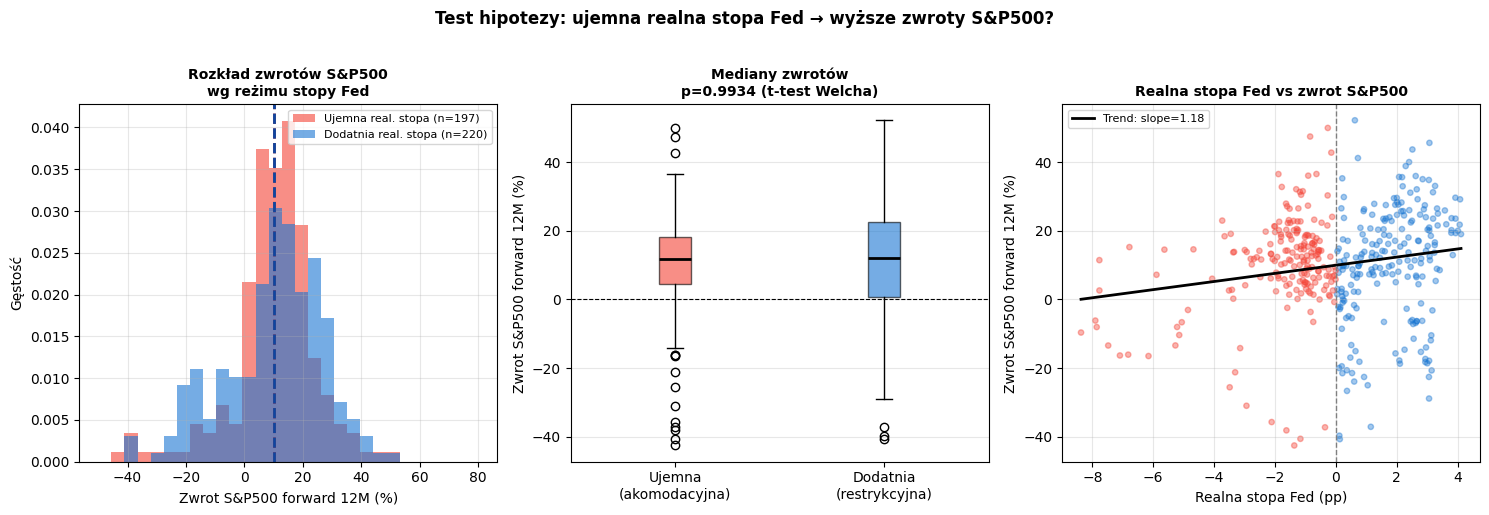

Zapisano: reports/04_test_hipotezy_sp500.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Rozkłady zwrotów (histogram)
ax = axes[0]
bins = np.linspace(-50, 80, 30)
ax.hist(neg_rate, bins=bins, color='#f44336', alpha=0.6, label=f'Ujemna real. stopa (n={len(neg_rate)})', density=True)
ax.hist(pos_rate, bins=bins, color='#1976d2', alpha=0.6, label=f'Dodatnia real. stopa (n={len(pos_rate)})', density=True)
ax.axvline(neg_rate.mean(), color='#d32f2f', linestyle='--', linewidth=2)
ax.axvline(pos_rate.mean(), color='#0d47a1', linestyle='--', linewidth=2)
ax.set_xlabel('Zwrot S&P500 forward 12M (%)')
ax.set_ylabel('Gęstość')
ax.set_title('Rozkład zwrotów S&P500\nwg reżimu stopy Fed', fontsize=10, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Panel 2: Boxplot
ax = axes[1]
bp = ax.boxplot([neg_rate.values, pos_rate.values],
                labels=['Ujemna\n(akomodacyjna)', 'Dodatnia\n(restrykcyjna)'],
                patch_artist=True, notch=False,
                medianprops={'color': 'black', 'linewidth': 2})
bp['boxes'][0].set_facecolor('#f44336'); bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#1976d2'); bp['boxes'][1].set_alpha(0.6)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Zwrot S&P500 forward 12M (%)')
ax.set_title(f'Mediany zwrotów\np={p_val:.4f} (t-test Welcha)', fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Panel 3: Scatter - realna stopa vs zwrot 12M
ax = axes[2]
color_scatter = ['#f44336' if r < 0 else '#1976d2' for r in analysis['real_rate']]
ax.scatter(analysis['real_rate'], analysis['sp500_fwd12'],
           c=color_scatter, alpha=0.4, s=15)
# Linia trendu
z = np.polyfit(analysis['real_rate'], analysis['sp500_fwd12'], 1)
p_line = np.poly1d(z)
x_range = np.linspace(analysis['real_rate'].min(), analysis['real_rate'].max(), 100)
ax.plot(x_range, p_line(x_range), color='black', linewidth=2, label=f'Trend: slope={z[0]:.2f}')
ax.axvline(0, color='gray', linewidth=1, linestyle='--')
ax.set_xlabel('Realna stopa Fed (pp)')
ax.set_ylabel('Zwrot S&P500 forward 12M (%)')
ax.set_title('Realna stopa Fed vs zwrot S&P500', fontsize=10, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle('Test hipotezy: ujemna realna stopa Fed → wyższe zwroty S&P500?',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/04_test_hipotezy_sp500.png', dpi=150, bbox_inches='tight')
plt.show()
print('Zapisano: reports/04_test_hipotezy_sp500.png')

## 5. Podsumowanie - wnioski analityczne Dnia 4

In [10]:
# Zbiorcze podsumowanie
last_real = real_rate.dropna().iloc[-1]
last_m2_yoy = m2_yoy.iloc[-1]
last_m2_mom = m2_mom.iloc[-1]

print('='*60)
print('WNIOSKI - DZIEŃ 4: ANALIZA STATYSTYCZNA')
print('='*60)
print()
print(f'📍 Data analizy: {last_date.strftime("%Y-%m")}')
print()
print('1. PERCENTYLE WSKAŹNIKÓW')
for _, row in pct_df.iterrows():
    print(f'   {row["Ocena"]}  {row.name}: {row["Percentyl"]:.0f}. percentyl ({row["Aktualna wartość"]})')
print()
print('2. M2 MOMENTUM')
print(f'   M2 YoY: {last_m2_yoy:.2f}%')
print(f'   Momentum 6M: {last_m2_mom:+.2f} pp  → {"przyspieszenie" if last_m2_mom > 0 else "hamowanie"} podaży pieniądza')
print()
print('3. REALNA STOPA FED')
print(f'   Aktualna: {last_real:+.2f} pp  → {"UJEMNA (akomodacyjna)" if last_real < 0 else "DODATNIA (restrykcyjna)"}')
print()
print('4. TEST HIPOTEZY (ujemna real. stopa Fed → wyższe zwroty S&P500)')
print(f'   Średni zwrot przy ujemnej stopie: {neg_rate.mean():.1f}%')
print(f'   Średni zwrot przy dodatniej stopie: {pos_rate.mean():.1f}%')
print(f'   p-wartość t-testu: {p_val:.4f} → {"✅ istotne" if p_val < 0.05 else "❌ nieistotne"} (α=0.05)')

WNIOSKI - DZIEŃ 4: ANALIZA STATYSTYCZNA

📍 Data analizy: 2026-09

1. PERCENTYLE WSKAŹNIKÓW
   🟢 Nisko  Yield Curve 10Y-2Y (pp): 32. percentyl (0.4)
   🟢 Nisko  HY Spread (pp): 2. percentyl (2.68)

2. M2 MOMENTUM
   M2 YoY: 5.41%
   Momentum 6M: +1.36 pp  → przyspieszenie podaży pieniądza

3. REALNA STOPA FED
   Aktualna: +0.28 pp  → DODATNIA (restrykcyjna)

4. TEST HIPOTEZY (ujemna real. stopa Fed → wyższe zwroty S&P500)
   Średni zwrot przy ujemnej stopie: 10.1%
   Średni zwrot przy dodatniej stopie: 10.1%
   p-wartość t-testu: 0.9934 → ❌ nieistotne (α=0.05)
